# SDSS fit: J102839.11+450009.4 with tight Fe FWHM priors

This notebook fetches the SDSS spectrum for `J102839.11+450009.4`, overrides Fe UV/optical FWHM priors, and fits with `decompose_host=False`.

Set `config.inference.method = "optax"` for staged SVI/Optax MAP optimization (continuum warm start, then full model). Set `config.inference.method = "optax+nuts"` to use that staged MAP point to initialize NUTS.


In [1]:
import numpy as np
from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
from astropy import units as u

import jaxqsofit
from jaxqsofit import (
    ContinuumConfig,
    HostConfig,
    InferenceConfig,
    JAXQSOFit,
    LineConfig,
    Observation,
    OutputConfig,
    FitConfig,
    SpectroscopyData,
)


/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
coord = SkyCoord.from_name("J102839.11+450009.4")
xid = SDSS.query_region(coord, spectro=True, radius=5 * u.arcsec)
sp = SDSS.get_spectra(matches=xid[:1])[0]

tb = sp[1].data
lam = np.asarray(10 ** tb["loglam"], dtype=float)
flux = np.asarray(tb["flux"], dtype=float)
ivar = np.asarray(tb["ivar"], dtype=float)

err = np.full_like(flux, 1e-6)
m = np.isfinite(ivar) & (ivar > 0)
err[m] = 1.0 / np.sqrt(ivar[m])

z = float(sp[2].data["z"][0])
ra = float(coord.ra.deg)
dec = float(coord.dec.deg)
plateid = int(sp[0].header.get("plateid", 0))
mjd = int(sp[0].header.get("mjd", 0))
fiberid = int(sp[0].header.get("fiberid", 0))
sdss_filename = f"{plateid:04d}-{mjd}-{fiberid:04d}"

lam.size, z, sdss_filename


(3831, 0.5834615230560303, '1429-52990-0401')

In [3]:
flux_rest = flux * (1 + z)
prior_config = jaxqsofit.defaults.build_default_prior_config(flux=flux_rest)

fscale = np.nanmedian(np.abs(flux_rest[np.isfinite(flux_rest)]))

prior_config["log_Fe_uv_norm"] = {
    "dist": "LogNormal",
    "loc": np.log(max(0.03 * fscale, 1e-12)),
    "scale": 1.0,
}
prior_config["log_Fe_op_over_uv"] = {
    "dist": "Normal",
    "loc": 0.0,
    "scale": 1.0,
}
prior_config["log_Fe_uv_FWHM"] = {
    "dist": "LogNormal",
    "loc": np.log(3000.0),
    "scale": 0.5,
}
prior_config["log_Fe_op_FWHM"] = {
    "dist": "LogNormal",
    "loc": np.log(3000.0),
    "scale": 0.5,
}

100%|██████████| 200/200 [00:00<00:00, 704.56it/s, init loss: 19323.8351, avg. loss [191-200]: 11469.2192]


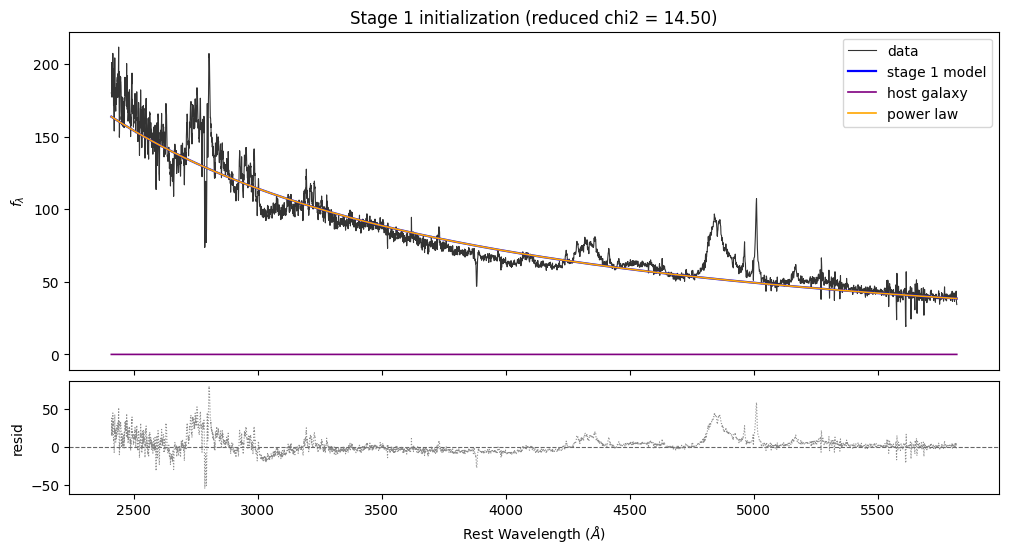

In [ ]:
cfg = FitConfig(
    observation=Observation(
        object_id=sdss_filename,
        redshift=z,
        ra=ra,
        dec=dec,
        apply_mw_deredden=True,
    ),
    spectroscopy=SpectroscopyData(wave_obs=lam, fluxes=flux, errors=err),
    continuum=ContinuumConfig(
        fit_power_law=True,
        fit_feii=True,
        fit_balmer_continuum=False,
        fit_polynomial_tilt=True,
    ),
    host=HostConfig(enabled=False, dsps_ssp_fn='../tempdata.h5'),
    lines=LineConfig(enabled=True),
    inference=InferenceConfig(
        method='optax+nuts',
        map_steps=600,
        learning_rate=1e-2,
        num_warmup=50,
        num_samples=50,
        num_chains=1,
        plot_init=True,
    ),
    output=OutputConfig(output_path='.', save_result=False, plot_fig=True, save_fig=False),
    prior_config=prior_config,
)

q = JAXQSOFit(cfg)
result = q.fit()


In [ ]:
q.plot_mcmc_diagnostics(
    param_names='Fe_uv_FWHM',
    do_trace=True,
    do_corner=True,
    max_vector_elems=2,
    corner_bins=25,
    corner_max_points=1500,
)
